# Notebook 01: Encoder Benchmark

Re-evaluation of the embedding-based zero-shot classifier from the partner firm's
prior prototype (`Masterthesis_Team3_contract_checker`). This notebook reproduces
the original pipeline under identical configuration (encoder weights, pooling
strategy, reference text construction) and produces the metrics that will be
compared against the LLM-based classifier in Notebook 02.

## Methodology

**Task.** For each of the 64 manually labelled contract sections, predict the
catalogue entry (out of 76) that best describes the clause. Predictions are
compared against the manually assigned gold `catalog_id`.

**System under evaluation.** Sentence-Transformer model
`paraphrase-multilingual-MiniLM-L12-v2` with mean pooling, used out-of-the-box
without fine-tuning. Classification is performed by encoding each section and
each catalogue reference text, computing cosine similarity between every
section and every reference, and selecting the catalogue entry with the highest
similarity (argmax). Reference text is the catalogue's `example` field, matching
the original prototype.

**Determinism.** The model is set to `eval()` mode to disable dropout. Torch and
NumPy random seeds are fixed. This is the empirical test of the determinism
claim made in Section 2.3.5 of the thesis.

**Statistical inference.** Bootstrap confidence intervals (B=1000) on the full
64-section set rather than cross-validation. No training occurs, so the
standard rationale for cross-validation does not apply.

**Stability protocol.** N=5 runs on identical inputs with identical
configuration. Stability score is the fraction of inputs for which all five
runs produce the same prediction.

**Threshold.** The original prototype applied a ROC-derived similarity threshold
to filter low-confidence matches into a `-99` no-match class. This threshold is
fitted in-sample and therefore inflates metrics. For comparability with the LLM
in Notebook 02 (which has no equivalent threshold mechanism), the primary
evaluation here uses pure argmax. The threshold variant can be added later as a
sensitivity analysis.

## Setup

In [17]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import confusion_matrix

# Make project root importable so we can use src.metrics
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))
from src import metrics as M

DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results" / "encoder"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Configuration
MODEL_NAME = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
POOLING_STRATEGY = "mean"
SEED = 42
N_STABILITY_RUNS = 5
N_BOOTSTRAP_RESAMPLES = 1000

print(f"Project root: {PROJECT_ROOT}")
print(f"Torch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

# Suppress harmless sklearn warnings about high class count relative to sample size
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

Project root: c:\Dev\masterthesis-benchmark
Torch version: 2.7.1+cpu
CUDA available: False


## Step 1: Load and validate data

We load the labelled sections and the requirement catalogue from the partner
firm's original prototype. The catalogue file `catalogue_clean_with_aspects.xlsx`
contains additional columns (`core_aspects`, `prompts ab zeile 46`) that were
used by the prototype's downstream fulfilment-scoring stage. They are dropped
here because they have no role in topic classification.

The `catalog_id` column does not exist in our copy of the catalogue, so we
reconstruct it as `index + 1`, matching the 1-indexed gold labels in the
sections file. An assertion verifies that every gold label maps to a catalogue
entry.

In [18]:
sections = pd.read_excel(DATA_DIR / "sections_labeled_manually.xlsx")
sections = sections.drop(columns=["Unnamed: 0"], errors="ignore")
catalogue_raw = pd.read_excel(DATA_DIR / "catalogue_clean_with_aspects.xlsx")

# Drop columns not relevant to classification
catalogue = catalogue_raw[["paragraph_topic", "section_topic", "example"]].copy()
catalogue["catalog_id"] = catalogue.index + 1

print(f"Sections: {len(sections)} rows, {sections.shape[1]} columns")
print(f"Catalogue: {len(catalogue)} rows")
print(f"\nGold catalog_id range: [{sections['catalog_id'].min()}, {sections['catalog_id'].max()}]")
print(f"Unique gold catalog_ids: {sections['catalog_id'].nunique()} of 76 possible")
print(f"Catalogue classes with no test instance: {76 - sections['catalog_id'].nunique()}")

# Validation
gold_ids = set(sections["catalog_id"])
catalogue_ids = set(catalogue["catalog_id"])
assert gold_ids.issubset(catalogue_ids), (
    f"Gold labels contain catalog_ids not in catalogue: {gold_ids - catalogue_ids}"
)
print("\nValidation passed: every gold label maps to a catalogue entry.")

Sections: 64 rows, 6 columns
Catalogue: 76 rows

Gold catalog_id range: [1, 76]
Unique gold catalog_ids: 62 of 76 possible
Catalogue classes with no test instance: 14

Validation passed: every gold label maps to a catalogue entry.


In [19]:
sections.head(3)

,contract,paragraph,section,section_content,clean_section_content,catalog_id
0,2,§ 7,(1),(1) Zahlungszeitraum und Höhe der richten sic...,zahlungszeitraum und höhe der richten sich ebe...,1
1,2,§ 12,(2),(2) Die außerordentliche Kündigung aus wichtig...,die außerordentliche kündigung aus wichtigem g...,69
2,4,3.,3.2,3.2. Support und SLA 3.2.1. SAP erbringt Suppo...,support und sla sap erbringt support für den c...,31


In [20]:
catalogue.head(3)

,paragraph_topic,section_topic,example,catalog_id
0,Projektkosten_und_Zahlungsmodalitäten,Sind sämtliche Kostenarten und -bestandteile (...,Im Festpreis von € sind sämtliche Leistungen e...,1
1,Projektkosten_und_Zahlungsmodalitäten,Ist das Vergütungsmodell eindeutig festgelegt ...,Der Kunde zahlt eine monatliche Pauschale von ...,2
2,Projektkosten_und_Zahlungsmodalitäten,Ist ein Zahlungsplan mit konkreten Fälligkeite...,Die Vergütung ist in drei Raten zahlbar 30 bei...,3


## Step 2: Build reference texts and section inputs

**Reference text.** The original prototype encodes only the `example` column as
the reference representation for each catalogue entry. We adopt this exactly to
keep the re-evaluation faithful to the system being evaluated.

**Section input.** The prototype uses `clean_section_content`, a lowercased
version of the section text with punctuation removed. We adopt this for the
encoder run. For the LLM run in Notebook 02, the unprocessed `section_content`
will be used instead, since LLMs benefit from casing and punctuation. This
asymmetry in preprocessing reflects each system's native input format.

In [21]:
def build_reference_text(catalogue_row: pd.Series) -> str:
    """
    Reference text construction for catalogue entries.

    Matches the original prototype, which uses the `example` field only.
    To experiment with richer reference texts (e.g. concatenation of
    paragraph_topic + section_topic + example), modify this function.
    """
    return catalogue_row["example"]


section_texts = sections["clean_section_content"].tolist()
reference_texts = catalogue.apply(build_reference_text, axis=1).tolist()

print(f"Number of section texts: {len(section_texts)}")
print(f"Number of reference texts: {len(reference_texts)}")
print(f"\nExample section (truncated): {section_texts[0][:200]}...")
print(f"Example reference (truncated): {reference_texts[0][:200]}...")

Number of section texts: 64
Number of reference texts: 76

Example section (truncated): zahlungszeitraum und höhe der richten sich ebenso wie die zahlungsweise nach dem jeweils gültigen preisverzeichnis...
Example reference (truncated): Im Festpreis von € sind sämtliche Leistungen einschließlich Softwarelizenzen Implementierung Schulungen und ein Jahr Wartung enthalten Weitere Kosten entstehen nur bei schriftlicher Beauftragung zusät...


## Step 3: Load encoder and verify configuration

The model is loaded from HuggingFace on the first run (cached locally
afterwards). We then verify that the pooling strategy is `mean` as configured
by the model card, and explicitly set the model to `eval()` mode. This disables
dropout, which would otherwise introduce non-determinism during inference and
contradict the determinism claim in Chapter 2.3.5.

In [22]:
torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"Loading model: {MODEL_NAME}")
model = SentenceTransformer(MODEL_NAME)
model.eval()  # disable dropout

# Verify pooling configuration
pooling_module = model[1]
actual_pooling = pooling_module.get_pooling_mode_str()
print(f"Pooling mode reported by model: {actual_pooling}")
assert actual_pooling == POOLING_STRATEGY, (
    f"Expected '{POOLING_STRATEGY}' pooling, got '{actual_pooling}'"
)
print(f"Embedding dimension: {model.get_sentence_embedding_dimension()}")

Loading model: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Pooling mode reported by model: mean
Embedding dimension: 384


## Step 4: Compute embeddings and classify

Sections and references are encoded in two passes, then a cosine similarity
matrix of shape `(64, 76)` is computed. For each section, the argmax selects
the catalogue entry with the highest similarity. The corresponding `catalog_id`
becomes the predicted label.

In [23]:
def encode_and_classify(model, section_texts, reference_texts, catalogue):
    """Single pass: encode, similarity, argmax, return predictions DataFrame."""
    with torch.no_grad():
        section_emb = model.encode(
            section_texts,
            convert_to_numpy=True,
            show_progress_bar=True,
            normalize_embeddings=False,
        )
        reference_emb = model.encode(
            reference_texts,
            convert_to_numpy=True,
            show_progress_bar=True,
            normalize_embeddings=False,
        )

    similarity_matrix = cosine_similarity(section_emb, reference_emb)
    best_match_idx = similarity_matrix.argmax(axis=1)
    predicted_catalog_id = catalogue.loc[best_match_idx, "catalog_id"].values
    similarity_scores = similarity_matrix[np.arange(len(section_texts)), best_match_idx]

    return predicted_catalog_id, similarity_scores, similarity_matrix


# Run the primary pass
predicted_catalog_id, similarity_scores, similarity_matrix = encode_and_classify(
    model, section_texts, reference_texts, catalogue
)

predictions_df = pd.DataFrame({
    "contract": sections["contract"].values,
    "paragraph": sections["paragraph"].values,
    "section": sections["section"].values,
    "gold_catalog_id": sections["catalog_id"].values,
    "predicted_catalog_id": predicted_catalog_id,
    "similarity_score": similarity_scores,
    "correct": sections["catalog_id"].values == predicted_catalog_id,
})

print(f"\nPrimary pass complete: {predictions_df['correct'].sum()} / {len(predictions_df)} correct")
predictions_df.head(10)

Batches: 100%|██████████| 3/3 [00:00<00:00,  4.37it/s]


Primary pass complete: 21 / 64 correct


,contract,paragraph,section,gold_catalog_id,predicted_catalog_id,similarity_score,correct
0,2,§ 7,(1),1,4,0.678352,False
1,2,§ 12,(2),69,65,0.773302,False
2,4,3.,3.2,31,28,0.667198,False
3,4,5.,5.2,8,8,0.603390,True
4,4,6.,6.3,70,70,0.698530,True
5,4,12.,12.4,71,66,0.670721,False
6,4,12.,12.5,72,73,0.790204,False
7,5,2.,2.4,16,17,0.475195,False
8,6,2.,2.1,3,70,0.684078,False
9,6,3.,3.1,39,47,0.593947,False


## Step 5: Point metrics and bootstrap confidence intervals

Point metrics are computed on the full 64-section set. Bootstrap confidence
intervals are obtained by resampling section-prediction pairs with replacement
1000 times and recomputing each metric on every resample. The 95% percentile
interval gives the reported CI.

With 64 samples spread across 62 unique classes, expect wide intervals. This is
a property of the labelled data, not of the evaluation.

In [24]:
y_true = predictions_df["gold_catalog_id"].values
y_pred = predictions_df["predicted_catalog_id"].values

point_metrics = M.compute_point_metrics(y_true, y_pred)

print("Point metrics:")
for name, value in point_metrics.items():
    print(f"  {name:25s} {value:.4f}")

Point metrics:
  accuracy                  0.3281
  precision_macro           0.1887
  precision_weighted        0.2266
  recall_macro              0.2868
  recall_weighted           0.3281
  f1_macro                  0.2147
  f1_weighted               0.2510


In [25]:
print(f"Computing bootstrap CIs with B = {N_BOOTSTRAP_RESAMPLES} resamples ...")
ci_results = M.bootstrap_confidence_intervals(
    y_true, y_pred,
    n_resamples=N_BOOTSTRAP_RESAMPLES,
    confidence=0.95,
    random_state=SEED,
)

ci_table = pd.DataFrame([
    {
        "metric": name,
        "point": values["point"],
        "ci_low": values["ci_low"],
        "ci_high": values["ci_high"],
        "ci_width": values["ci_high"] - values["ci_low"],
    }
    for name, values in ci_results.items()
])
ci_table

Computing bootstrap CIs with B = 1000 resamples ...


,metric,point,ci_low,ci_high,ci_width
0,accuracy,0.328125,0.218750,0.437500,0.218750
1,precision_macro,0.188725,0.114363,0.269566,0.155203
2,precision_weighted,0.226562,0.153791,0.376855,0.223065
3,recall_macro,0.286765,0.163632,0.336778,0.173146
4,recall_weighted,0.328125,0.218750,0.437500,0.218750
5,f1_macro,0.214706,0.131030,0.287418,0.156388
6,f1_weighted,0.251042,0.171124,0.394825,0.223702


## Step 6: Stability run (N = 5)

Five passes through the encoder on identical inputs with identical
configuration. With `model.eval()` and fixed seeds, all five passes are expected
to produce bit-identical predictions. The stability score quantifies this:
fraction of sections for which all five runs return the same catalog_id.

This is the empirical validation of the determinism claim. If the stability is less than 1.0, the
encoder is not fully deterministic in this configuration and that finding has
to be documented.

In [26]:
all_predictions_per_run = []
all_metrics_per_run = []

for run_idx in range(N_STABILITY_RUNS):
    # Re-seed each run identically so we test true determinism, not seed variation
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    model.eval()

    pred, _, _ = encode_and_classify(model, section_texts, reference_texts, catalogue)
    all_predictions_per_run.append(pred)
    all_metrics_per_run.append(M.compute_point_metrics(y_true, pred))
    accuracy = (pred == y_true).mean()
    print(f"Run {run_idx + 1}: accuracy = {accuracy:.4f}")

stability, is_stable = M.stability_score(all_predictions_per_run)
print(f"\nStability score: {stability:.4f}")
print(f"Inputs with identical predictions across all {N_STABILITY_RUNS} runs: "
      f"{is_stable.sum()} / {len(is_stable)}")

Batches: 100%|██████████| 3/3 [00:00<00:00,  4.69it/s]


Run 1: accuracy = 0.3281


Batches: 100%|██████████| 3/3 [00:00<00:00,  4.46it/s]


Run 2: accuracy = 0.3281


Batches: 100%|██████████| 3/3 [00:00<00:00,  4.80it/s]


Run 3: accuracy = 0.3281


Batches: 100%|██████████| 3/3 [00:00<00:00,  4.52it/s]


Run 4: accuracy = 0.3281


Batches: 100%|██████████| 3/3 [00:00<00:00,  4.65it/s]

Run 5: accuracy = 0.3281

Stability score: 1.0000
Inputs with identical predictions across all 5 runs: 64 / 64


In [27]:
run_summary = M.summarise_metric_across_runs(all_metrics_per_run)
print(f"Metric variability across N={N_STABILITY_RUNS} runs:")
run_summary.round(4)

Metric variability across N=5 runs:


,mean,std,min,max
metric,,,,
accuracy,0.3281,0.0,0.3281,0.3281
precision_macro,0.1887,0.0,0.1887,0.1887
precision_weighted,0.2266,0.0,0.2266,0.2266
recall_macro,0.2868,0.0,0.2868,0.2868
recall_weighted,0.3281,0.0,0.3281,0.3281
f1_macro,0.2147,0.0,0.2147,0.2147
f1_weighted,0.2510,0.0,0.2510,0.2510


## Step 7: Confusion matrix and per-class breakdown

The confusion matrix shows the structure of misclassifications. With 62 unique
gold classes and mostly one sample per class, the matrix is sparse but reveals
which catalogue entries the model conflates. Diagonal cells are correct
predictions, off-diagonal cells are errors.

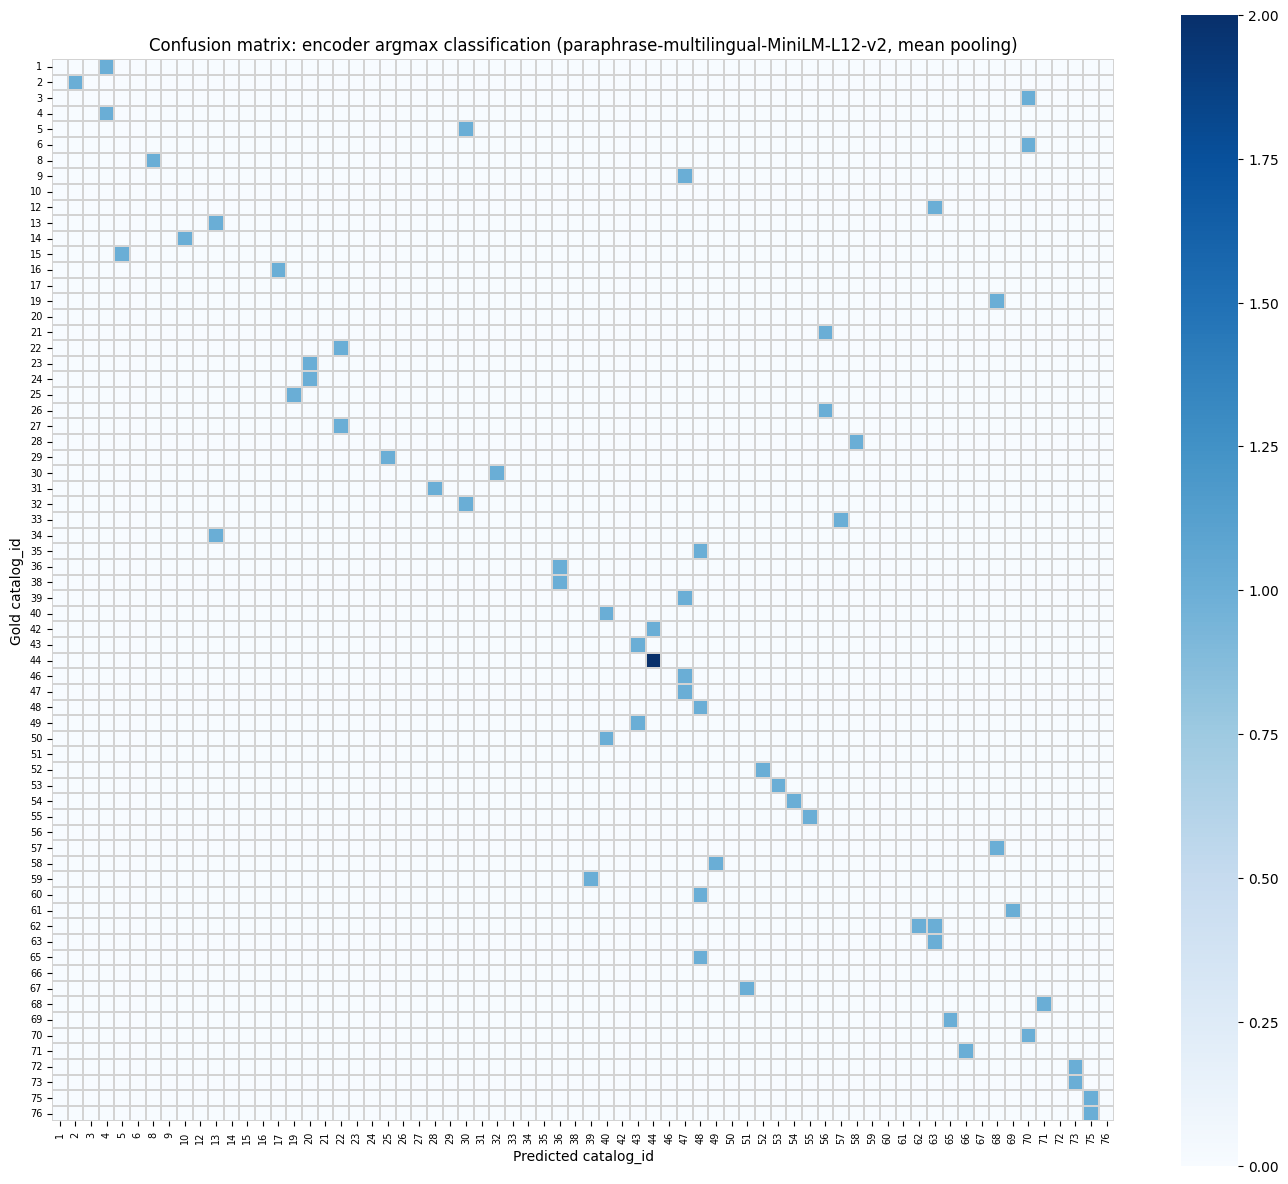

In [28]:
# Build confusion matrix over the union of gold and predicted IDs
labels_in_use = sorted(set(y_true) | set(y_pred))
cm = confusion_matrix(y_true, y_pred, labels=labels_in_use)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    cm,
    cmap="Blues",
    cbar=True,
    xticklabels=labels_in_use,
    yticklabels=labels_in_use,
    ax=ax,
    square=True,
    linewidths=0.3,
    linecolor="lightgrey",
)
ax.set_xlabel("Predicted catalog_id")
ax.set_ylabel("Gold catalog_id")
ax.set_title(f"Confusion matrix: encoder argmax classification ({MODEL_NAME.split('/')[-1]}, mean pooling)")
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

In [29]:
# Per-class breakdown
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    y_true, y_pred, labels=labels_in_use, zero_division=0
)

per_class_df = pd.DataFrame({
    "catalog_id": labels_in_use,
    "support": support,
    "precision": precision,
    "recall": recall,
    "f1": f1,
})
per_class_df = per_class_df.merge(
    catalogue[["catalog_id", "section_topic"]], on="catalog_id", how="left"
)
per_class_df = per_class_df[["catalog_id", "section_topic", "support", "precision", "recall", "f1"]]
per_class_df.sort_values("f1", ascending=False).head(20)

,catalog_id,section_topic,support,precision,recall,f1
47,54,"Ist festgehalten, dass Vertrags- und Leistungs...",1,1.000000,1.0,1.000000
46,53,Gibt es einen formalen Prozess für Leistungsän...,1,1.000000,1.0,1.000000
45,52,"Wird vom Anbieter verlangt, eine Haftpflichtve...",1,1.000000,1.0,1.000000
6,8,Sind Konsequenzen bei Zahlungsverzug geregelt ...,1,1.000000,1.0,1.000000
48,55,"Wird gefordert, dass bei jeder genehmigten Änd...",1,1.000000,1.0,1.000000
1,2,Ist das Vergütungsmodell eindeutig festgelegt ...,1,1.000000,1.0,1.000000
38,44,"Sind Ansprechpartner, Projektleiter und Gremie...",2,0.666667,1.0,0.800000
10,13,Werden geplante Schnittstellen zu Dritt-System...,1,0.500000,1.0,0.666667
18,22,"Gibt es objektive Kriterien oder Tests, nach d...",1,0.500000,1.0,0.666667
55,62,Sind bestimmte Schäden von der Haftung ausgesc...,2,1.000000,0.5,0.666667


## Step 8: Save outputs

All artefacts go to `results/encoder/` and are read by downstream notebooks and
the thesis figures. Predictions and metrics are versioned together so that any
result in the thesis text can be traced back to the exact predictions that
produced it.

In [30]:
# Predictions
predictions_df.to_csv(RESULTS_DIR / "predictions.csv", index=False)

# Metrics
metrics_output = {
    "model": MODEL_NAME,
    "pooling": POOLING_STRATEGY,
    "seed": SEED,
    "n_sections": int(len(sections)),
    "n_catalogue_entries": int(len(catalogue)),
    "n_unique_gold_classes": int(sections["catalog_id"].nunique()),
    "point_metrics": point_metrics,
    "bootstrap_ci": ci_results,
    "n_bootstrap_resamples": N_BOOTSTRAP_RESAMPLES,
    "stability_score": float(stability),
    "n_stability_runs": N_STABILITY_RUNS,
}
with open(RESULTS_DIR / "metrics.json", "w") as f:
    json.dump(metrics_output, f, indent=2)

# Per-class breakdown
per_class_df.to_csv(RESULTS_DIR / "per_class_breakdown.csv", index=False)

# Stability runs summary
run_summary.to_csv(RESULTS_DIR / "stability_runs.csv")

print("Saved to results/encoder/:")
for f in sorted(RESULTS_DIR.iterdir()):
    if f.name != ".gitkeep":
        print(f"  {f.name}")

Saved to results/encoder/:
  confusion_matrix.png
  metrics.json
  per_class_breakdown.csv
  predictions.csv
  stability_runs.csv


## Step 9: Seed sensitivity check

The stability run in Step 6 used a fixed seed across all five repetitions,
which tests determinism under identical configuration. This step
strengthens that test by varying the seed across runs. If the encoder is
fully deterministic under CPU inference and `model.eval()`, the
predictions should remain identical across all seeds, because the model
performs no internal sampling and applies no dropout during inference.

This is run as a quick proof of concept; results are not persisted. A
detailed sensitivity analysis with full metric variability across seeds
can be added later if needed for the thesis.

In [31]:
# Quick seed-sensitivity check (proof of concept, no output saved)
import torch as _torch

SEEDS_TO_TEST = [0, 1, 42, 100, 12345]
predictions_per_seed = []

print(f"Running encoder with {len(SEEDS_TO_TEST)} different seeds ...\n")
for seed in SEEDS_TO_TEST:
    _torch.manual_seed(seed)
    np.random.seed(seed)
    model.eval()

    with _torch.no_grad():
        section_emb_s = model.encode(
            section_texts,
            convert_to_numpy=True,
            show_progress_bar=False,
            normalize_embeddings=False,
        )
        reference_emb_s = model.encode(
            reference_texts,
            convert_to_numpy=True,
            show_progress_bar=False,
            normalize_embeddings=False,
        )

    sim_matrix = cosine_similarity(section_emb_s, reference_emb_s)
    best_match_idx = sim_matrix.argmax(axis=1)
    pred_s = catalogue.loc[best_match_idx, "catalog_id"].values
    predictions_per_seed.append(pred_s)

    acc_s = (pred_s == sections["catalog_id"].values).mean()
    print(f"  seed={seed:>6d}: accuracy={acc_s:.4f}")

# Stability across different seeds
stability_seeds, is_stable_seeds = M.stability_score(predictions_per_seed)
print(f"\nStability score across {len(SEEDS_TO_TEST)} different seeds: {stability_seeds:.4f}")
print(f"Sections with identical predictions across all seeds: {is_stable_seeds.sum()} / {len(is_stable_seeds)}")

if stability_seeds == 1.0:
    print("\nResult: The encoder is fully deterministic. Seed has no effect on predictions.")
else:
    print(f"\nResult: {(~is_stable_seeds).sum()} sections varied across seeds. Determinism is NOT bit-identical.")

Running encoder with 5 different seeds ...

  seed=     0: accuracy=0.3281
  seed=     1: accuracy=0.3281
  seed=    42: accuracy=0.3281
  seed=   100: accuracy=0.3281
  seed= 12345: accuracy=0.3281

Stability score across 5 different seeds: 1.0000
Sections with identical predictions across all seeds: 64 / 64

Result: The encoder is fully deterministic. Seed has no effect on predictions.


## Summary

| Artefact | File |
|---|---|
| Predictions per section | `results/encoder/predictions.csv` |
| Aggregated metrics with bootstrap CIs | `results/encoder/metrics.json` |
| Per-class precision, recall, F1 | `results/encoder/per_class_breakdown.csv` |
| Metric variability across N=5 runs | `results/encoder/stability_runs.csv` |
| Confusion matrix plot | `results/encoder/confusion_matrix.png` |
